In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO NORMANDIE REGION
print("\n🎯 FILTERING TO NORMANDIE REGION")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Filter to Normandie
df_quotes_normandie = df_quotes[df_quotes['nom_region'] == 'Normandie'].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Normandie customers: {df_quotes_normandie['numero_compte'].nunique():,}")
print(f"Quotes: {len(df_quotes_normandie):,}")

# Save to file
df_quotes_normandie.to_csv('cleaned_quote_data_normandie.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_normandie.csv")


🎯 FILTERING TO NORMANDIE REGION
Original customers: 25,716
Normandie customers: 11,001
Quotes: 15,938

✅ Saved to cleaned_quote_data_normandie.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_normandie.csv')


📊 Original quote data: 15,938 quotes from 11,001 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 11,001, Quotes: 15,353
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 11,001 customers | 42.5% converters
⏱️  Execution time: 4.4 seconds
⚠️  4.4s (target was 3s)
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 11,001
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/11,001 customers
  Processed 5,000/11,001 customers
  Processed 10,000/11,001 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 11,001
   First converters: 4,671 (42.5%)
   Never converters: 6,330

📊 Distribution check:
   Converters with 0 historical quotes: 3,860
   Non-converters with 0 historical quotes: 4,567
   Avg histori

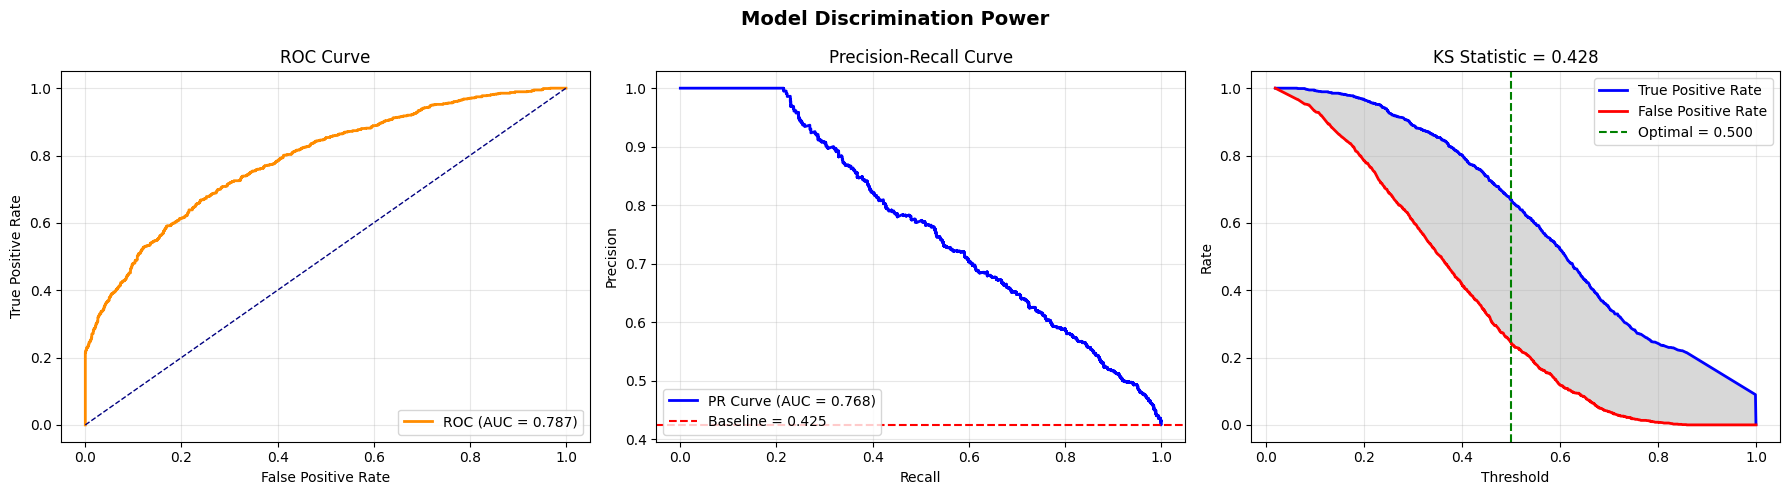

• ROC-AUC: 0.7872
• PR-AUC: 0.7679
• KS Statistic: 0.428 (GOOD discrimination)
• Optimal Threshold: 0.500

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.978
Decile 10 mean prob: 0.105


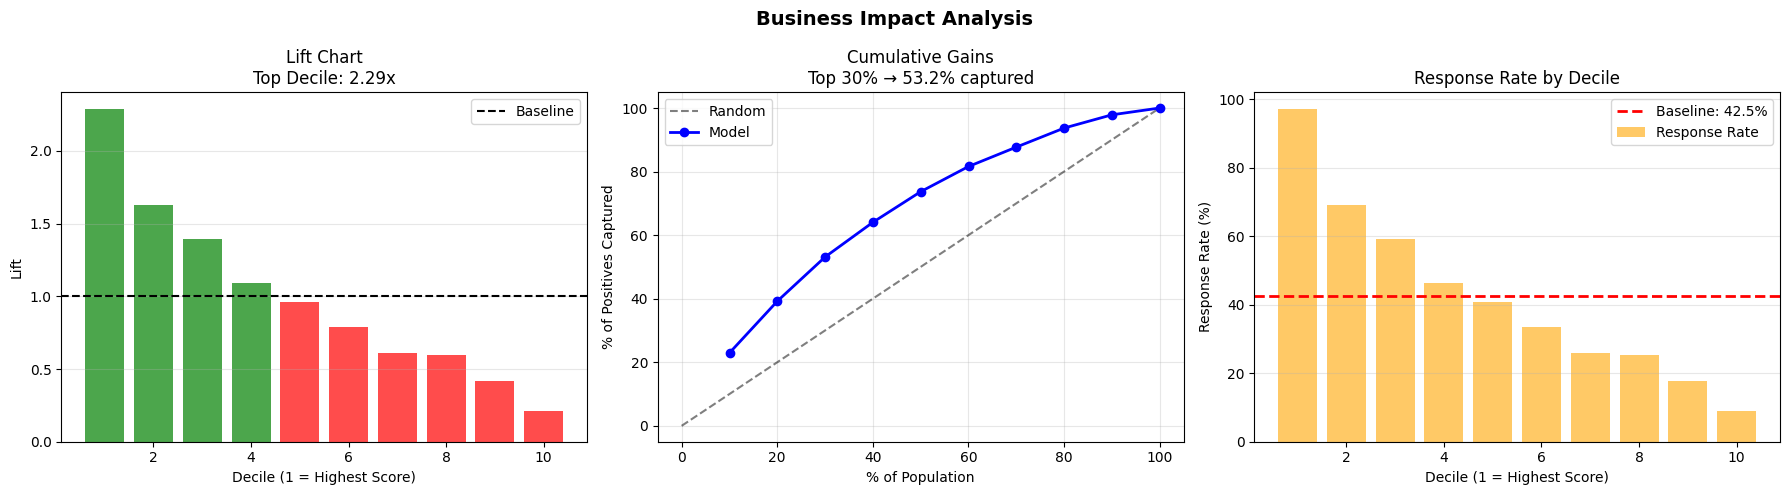

• Top Decile Lift: 0.21x
• Top 30% captures: 53.2% of positives
• Baseline response rate: 42.5%
• Top decile response: 97.3%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


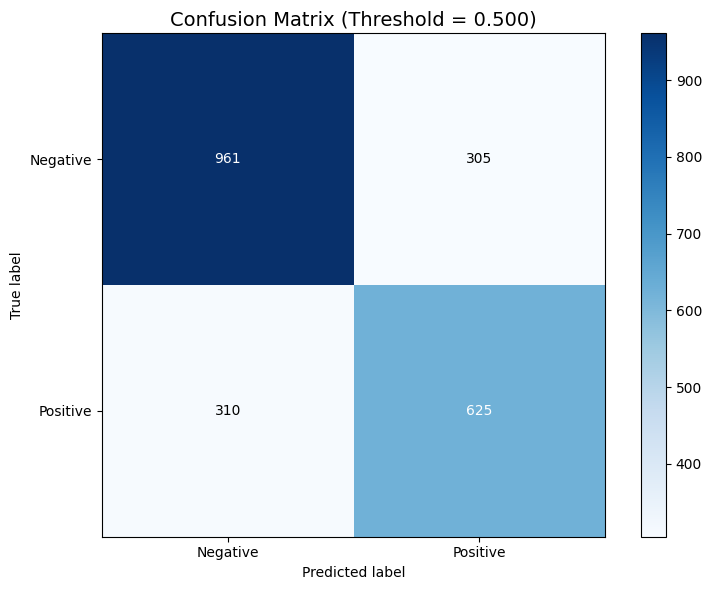

At threshold 0.500:
• Accuracy: 0.721
• Precision: 0.672
• Recall: 0.668
• F1-Score: 0.670
• True Positives: 625
• False Positives: 305
• True Negatives: 961
• False Negatives: 310

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.428 (GOOD discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.21x better than random
   Coverage: Top 30% → 53.2% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7872 (Excellent if >0.8)
   PR-AUC: 0.7679 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.500
   Precision at threshold: 0.672
   Recall at threshold: 0.668

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                             feature  importance
176          quote_consistency_score    0.105214
165                 is_quick_decider    0.032412
248                      value_score    0.032186
212           speed_complexity_ratio    0.029311
211     engagement_consistency_score    0.015816
36               model_variety_score    0.015069
58         

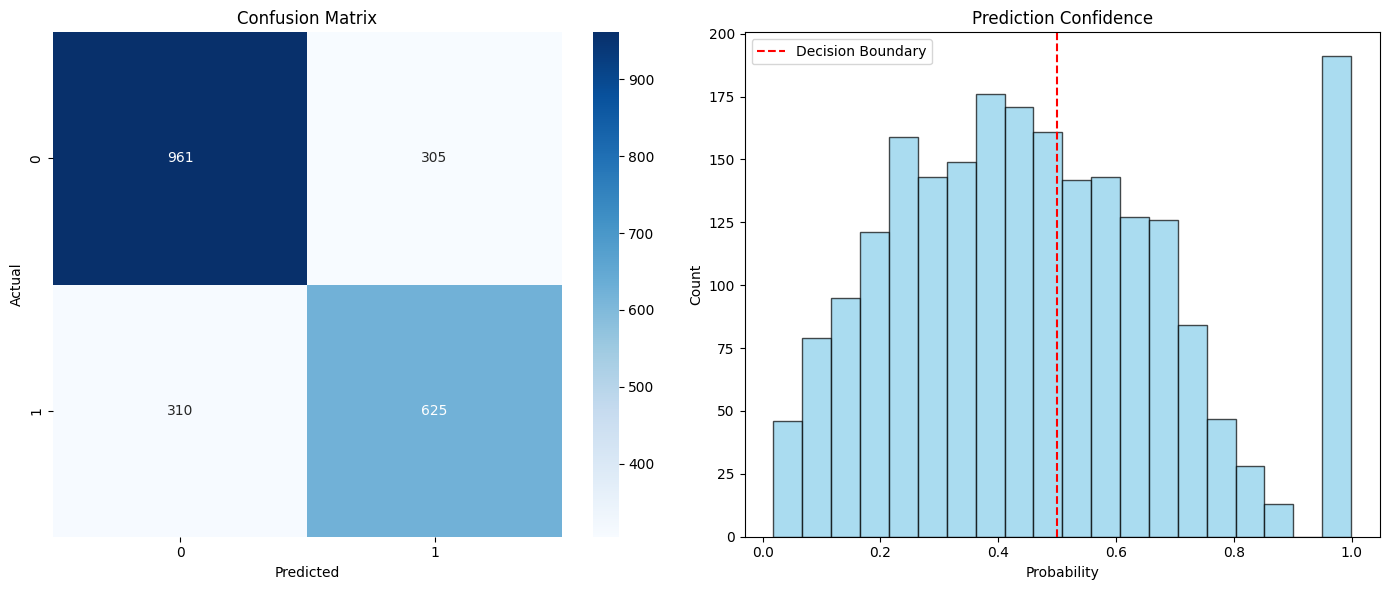

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])